In [1]:
import numpy as np

import torch
import torch.nn as nn
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.datasets.mnist import MNIST
from torchvision.transforms import ToTensor

In [2]:
import torch

def select_device(preferred_gpu_index=3):
    """
    Returns a torch.device object.
    Uses GPU at preferred index if available, else falls back to CPU.
    """
    if torch.cuda.is_available() and torch.cuda.device_count() > preferred_gpu_index:
        device = torch.device(f"cuda:{preferred_gpu_index}")
        print(f"✅ Using GPU {preferred_gpu_index}: {torch.cuda.get_device_name(preferred_gpu_index)}")
    else:
        device = torch.device("cpu")
        print("⚠️ GPU 3 not available. Using CPU.")
    return device

# Example usage
device = select_device()

✅ Using GPU 3: NVIDIA GeForce RTX 2080 Ti


In [3]:
# def train_ViT_classify(model, optimizer, N_EPOCHS, train_loader, device=device):
#     criterion = CrossEntropyLoss()
#     for epoch in range(N_EPOCHS):
#         train_loss = 0.0
#         for batch in train_loader:
#             x, y = batch
#             x = x.to(device)
#             y = y.to(device)
#             y_hat = model(x)
#             loss = criterion(y_hat, y) / len(x)

#             train_loss += loss.item()

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#         print(f"Epoch {epoch + 1}/{N_EPOCHS} loss: {train_loss:.2f}")
        
# def test_ViT_classify(model, optimizer, test_loader):
#     criterion = CrossEntropyLoss()
#     correct, total = 0, 0
#     test_loss = 0.0
#     for batch in test_loader:
#         x, y = batch
#         x = x.to(device)
#         y = y.to(device)
        
#         y_hat = model(x)
#         loss = criterion(y_hat, y) / len(x)
#         test_loss += loss

#         correct += torch.sum(torch.argmax(y_hat, dim=1) == y).item()
#         total += len(x)
#     print(f"Test loss: {test_loss:.2f}")
#     print(f"Test accuracy: {correct / total * 100:.2f}%")

In [4]:
from tqdm import tqdm
from torch.nn import CrossEntropyLoss

def train_ViT_classify(model, optimizer, N_EPOCHS, train_loader, device='cuda'):
    criterion = CrossEntropyLoss()
    model.to(device)

    for epoch in range(N_EPOCHS):
        train_loss = 0.0
        model.train()

        loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{N_EPOCHS}", leave=False)
        for x, y in loop:
            x = x.to(device)
            y = y.to(device)

            y_hat = model(x)
            loss = criterion(y_hat, y) / len(x)
            train_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch + 1}/{N_EPOCHS} total loss: {train_loss:.2f}")

In [5]:
from tqdm import tqdm
from torch.nn import CrossEntropyLoss

def test_ViT_classify(model, optimizer, test_loader, device='cuda'):
    criterion = CrossEntropyLoss()
    correct, total = 0, 0
    test_loss = 0.0
    model.eval()

    with torch.no_grad():
        loop = tqdm(test_loader, desc="Testing", leave=False)
        for x, y in loop:
            x = x.to(device)
            y = y.to(device)

            y_hat = model(x)
            loss = criterion(y_hat, y) / len(x)
            test_loss += loss.item()

            correct += torch.sum(torch.argmax(y_hat, dim=1) == y).item()
            total += len(x)

            loop.set_postfix(loss=loss.item(), accuracy=correct / total * 100)

    print(f"Test loss: {test_loss:.2f}")
    print(f"Test accuracy: {correct / total * 100:.2f}%")

In [6]:
class MSA(nn.Module):
    def __init__(self, d, n_heads=2):
        super(MSA, self).__init__()
        self.d = d
        self.n_heads = n_heads

        assert d % n_heads == 0, f"Can't divide dimension {d} into {n_heads} heads"

        d_head = int(d / n_heads)
        self.q_mappings = [nn.Linear(d_head, d_head) for _ in range(self.n_heads)]
        self.k_mappings = [nn.Linear(d_head, d_head) for _ in range(self.n_heads)]
        self.v_mappings = [nn.Linear(d_head, d_head) for _ in range(self.n_heads)]
        self.d_head = d_head
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, sequences):
        # Sequences has shape (N, seq_length, token_dim)
        # We go into shape    (N, seq_length, n_heads, token_dim / n_heads)
        # And come back to    (N, seq_length, item_dim)  (through concatenation)
        result = []
        for sequence in sequences:
            seq_result = []
            for head in range(self.n_heads):
                q_mapping = self.q_mappings[head].to(device)
                k_mapping = self.k_mappings[head].to(device)
                v_mapping = self.v_mappings[head].to(device)

                seq = sequence[:, head * self.d_head: (head + 1) * self.d_head]
                q, k, v = q_mapping(seq), k_mapping(seq), v_mapping(seq)

                attention = self.softmax(q @ k.T / (self.d_head ** 0.5))
                seq_result.append(attention @ v)
            result.append(torch.hstack(seq_result))
        return torch.cat([torch.unsqueeze(r, dim=0) for r in result])

In [7]:
def get_positional_embeddings(sequence_length, d, device=device):
    result = torch.ones(sequence_length, d)
    for i in range(sequence_length):
        for j in range(d):
            result[i][j] = np.sin(i / (10000 ** (j / d))) if j % 2 == 0 else np.cos(i / (10000 ** ((j - 1) / d)))
    return result.to(device)

In [8]:
class ViT(nn.Module):
    def __init__(self, input_shape, n_patches=7, hidden_d=8, n_heads=2, out_d=10):
        # Super constructor
        super(ViT, self).__init__()

        # Input and patches sizes
        self.input_shape = input_shape
        self.n_patches = n_patches
        self.n_heads = n_heads
        assert input_shape[1] % n_patches == 0, "Input shape not entirely divisible by number of patches"
        assert input_shape[2] % n_patches == 0, "Input shape not entirely divisible by number of patches"
        self.patch_size = (input_shape[1] / n_patches, input_shape[2] / n_patches)
        self.hidden_d = hidden_d

        # 1) Linear mapper
        self.input_d = int(input_shape[0] * self.patch_size[0] * self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)

        # 2) Classification token
        self.class_token = nn.Parameter(torch.rand(1, self.hidden_d))

        # 3) Positional embedding
        # (In forward method)

        # 4a) Layer normalization 1
        self.ln1 = nn.LayerNorm((self.n_patches ** 2 + 1, self.hidden_d))

        # 4b) Multi-head Self Attention (MSA) and classification token
        self.msa = MSA(self.hidden_d, n_heads)

        # 5a) Layer normalization 2
        self.ln2 = nn.LayerNorm((self.n_patches ** 2 + 1, self.hidden_d))

        # 5b) Encoder MLP
        self.enc_mlp = nn.Sequential(
            nn.Linear(self.hidden_d, self.hidden_d),
            nn.ReLU()
        )

        # 6) Classification MLP
        self.mlp = nn.Sequential(
            nn.Linear(self.hidden_d, out_d),
            nn.Softmax(dim=-1)
        )

    def forward(self, images):
        # Dividing images into patches
        n, c, w, h = images.shape
        patches = images.reshape(n, self.n_patches ** 2, self.input_d)

        # Running linear layer for tokenization
        tokens = self.linear_mapper(patches)

        # Adding classification token to the tokens
        tokens = torch.stack([torch.vstack((self.class_token, tokens[i])) for i in range(len(tokens))])

        # Adding positional embedding
        tokens += get_positional_embeddings(self.n_patches ** 2 + 1, self.hidden_d, device).repeat(n, 1, 1)

        # TRANSFORMER ENCODER BEGINS ###################################
        # NOTICE: MULTIPLE ENCODER BLOCKS CAN BE STACKED TOGETHER ######
        # Running Layer Normalization, MSA and residual connection
        # print(tokens)
        self.msa(self.ln1(tokens))
        out = tokens + self.msa(self.ln1(tokens))

        # Running Layer Normalization, MLP and residual connection
        out = out + self.enc_mlp(self.ln2(out))
        # TRANSFORMER ENCODER ENDS   ###################################

        # Getting the classification token only
        out = out[:, 0]

        return self.mlp(out)

In [9]:

model = ViT((1, 28, 28), n_patches=7, hidden_d=20, n_heads=2, out_d=10)
model = model.to(device)

N_EPOCHS = 5
LR = 0.01
optimizer = Adam(model.parameters(), lr=LR)

In [10]:
# !rm -rf Datasets/MNIST

In [11]:
transform = ToTensor()

train_set = MNIST(root='./Datasets', train=True, download=True, transform=transform)
test_set = MNIST(root='./Datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, shuffle=True, batch_size=16)
test_loader = DataLoader(test_set, shuffle=False, batch_size=16)

In [12]:

train_ViT_classify(model, optimizer, N_EPOCHS, train_loader, device)

Epoch 1/5 total loss: 409.00


Epoch 2/5 total loss: 383.61


Epoch 3/5 total loss: 370.99


Epoch 4/5 total loss: 368.11


Epoch 5/5 total loss: 366.52


In [13]:
test_ViT_classify(model, optimizer, test_loader,device)

Test loss: 60.66
Test accuracy: 90.89%


## Pytouch Vit

In [14]:

# !pip install vit-pytorch

In [15]:
import torch
from vit_pytorch import ViT

v = ViT(
    image_size = 256,
    patch_size = 32,
    num_classes = 1000,
    dim = 1024,
    depth = 6,
    heads = 16,
    mlp_dim = 2048,
    dropout = 0.1,
    emb_dropout = 0.1
)

img = torch.randn(1, 3, 256, 256)

preds = v(img) # (1, 1000)

In [16]:
import torch
from torchvision.models import resnet50

from vit_pytorch.distill import DistillableViT, DistillWrapper

teacher = resnet50(pretrained = True)

v = DistillableViT(
    image_size = 256,
    patch_size = 32,
    num_classes = 1000,
    dim = 1024,
    depth = 6,
    heads = 8,
    mlp_dim = 2048,
    dropout = 0.1,
    emb_dropout = 0.1
)

distiller = DistillWrapper(
    student = v,
    teacher = teacher,
    temperature = 3,           # temperature of distillation
    alpha = 0.5,               # trade between main loss and distillation loss
    hard = False               # whether to use soft or hard distillation
)

img = torch.randn(2, 3, 256, 256)
labels = torch.randint(0, 1000, (2,))

loss = distiller(img, labels)
loss.backward()

# after lots of training above ...

pred = v(img)

/home/jupyter-125333/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jupyter-125333/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
import os
# os.environ['http_proxy']="http://192.41.170.23:3128"
# os.environ['https_proxy']="http://192.41.170.23:3128"

import torch
import torch.nn as nn
from torchvision.models import vit_b_16 as ViT, ViT_B_16_Weights
model = ViT(weights=ViT_B_16_Weights.DEFAULT)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"{total_params/1000000}M")

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [18]:
# Changed to out_features = 100
model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=100, bias=True))

# Set the GPU Device
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
print(device)

# Move the model to Device
model.to(device)
print("Classifier Head: ", model.heads)
# Initiate the weights and biases
for m in model.heads:
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.normal_(m.bias, std=1e-6)
    # print(m.weight)
    # print(m.bias)

cuda:1
Classifier Head:  Sequential(
  (0): Linear(in_features=768, out_features=100, bias=True)
)


In [19]:
from torch.utils.data import Dataset
import torch
import cv2 # requires !pip3 install opencv-python
import os
import pandas as pd
from skimage import io


class SportDataset(Dataset):
    """Sport dataset."""

    def __init__(self, csv_file, root_dir, class_file, train=True, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            class_file (string): Path to the csv file with class names and indices.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        classes = pd.read_csv(class_file)
        self.class_dict = {row[1]:row[0] for i, row in classes.iterrows()}

        df = pd.read_csv(csv_file)
        if train:
            self.df = df[df['data set'] == 'train']
        else:
            self.df = df[df['data set'] == 'valid']

        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = os.path.join(self.root_dir,
                                self.df.iloc[idx, 1])
        try:
            image = io.imread(img_name)
        

            if image.shape[-1] != 3:
                image = cv2.cvtColor(image,cv2.COLOR_GRAY2RGB)
    
            if self.transform:
                image = self.transform(image)
            label_keys = self.df.iloc[idx, 2]
            labels = self.class_dict[label_keys]
            labels = float(labels)
    
            sample = {'image': image, 'labels': labels}
        except OSError as e:
            print(f"Skipping file {img_name}: {e}")
            return self.__getitem__((idx + 1) % len(self.df))  # Try next index

        return sample

In [20]:
import requests
def download_big_file(dest_path,url):
    # Ensure destination directory exists
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)

    if os.path.exists(dest_path):
        print(f"✅ Skipping {os.path.basename(dest_path)} (already exists)")
        return

    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))

    with open(dest_path, 'wb') as file, tqdm(
        desc=os.path.basename(dest_path),
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)

In [21]:
import zipfile

def unzip_folder(zip_path, extract_to, sub_dir="train"):
    expected_path = os.path.join(extract_to, sub_dir)
    if os.path.exists(expected_path) and any(os.scandir(expected_path)):
        print(f"⚠️ Skipping extraction: {expected_path} already populated")
        return

    print(f"📦 Extracting {os.path.basename(zip_path)} → {extract_to}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in tqdm(zip_ref.infolist(), desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

In [22]:
raw_zip_dir = "DLCV_Lab_Dataset/raw_zips/sports-classification.zip"
source_url = "https://www.kaggle.com/api/v1/datasets/download/gpiosenka/sports-classification"
download_big_file(raw_zip_dir, source_url)

✅ Skipping sports-classification.zip (already exists)


In [23]:
zip_path = "DLCV_Lab_Dataset/raw_zips/sports-classification.zip"
extract_path = "DLCV_Lab_Dataset/sports-classification"
unzip_folder(zip_path, extract_path)

⚠️ Skipping extraction: DLCV_Lab_Dataset/sports-classification/train already populated


In [24]:
# !rm -rf DLCV_Lab_Dataset/test DLCV_Lab_Dataset/train DLCV_Lab_Dataset/valid

In [25]:

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torch


# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

In [26]:
import os
import pandas as pd

def create_class_dict_csv(train_dir, output_csv='class_dict.csv'):
    """
    Scans subfolders in the train_dir and creates a CSV mapping class names to integer indices.
    
    Args:
        train_dir (str): Path to the training directory containing class subfolders.
        output_csv (str): Filename for the output CSV.
    
    Returns:
        dict: Dictionary mapping class names to indices.
    """
    # Get all subdirectories (class names)
    class_names = sorted([
        name for name in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, name))
    ])

    # Create mapping
    class_dict = {idx:name for idx, name in enumerate(class_names)}

    # Save to CSV
    df = pd.DataFrame(list(class_dict.items()), columns=['class_index','class'])
    df.to_csv(output_csv, index=False)

    print(f"Saved {len(class_dict)} classes to {output_csv}")
    return class_dict

In [27]:
csv_file = 'DLCV_Lab_Dataset/sports-classification/sports.csv'
class_file = 'DLCV_Lab_Dataset/sports-classification/class_dict.csv'
root_dir = 'DLCV_Lab_Dataset/sports-classification'

In [28]:
class_dict = create_class_dict_csv(train_dir=root_dir+'/train',output_csv=root_dir+'/class_dict.csv')


Saved 100 classes to DLCV_Lab_Dataset/sports-classification/class_dict.csv


class dict:  {0: 'air hockey', 1: 'ampute football', 2: 'archery', 3: 'arm wrestling', 4: 'axe throwing', 5: 'balance beam', 6: 'barell racing', 7: 'baseball', 8: 'basketball', 9: 'baton twirling', 10: 'bike polo', 11: 'billiards', 12: 'bmx', 13: 'bobsled', 14: 'bowling', 15: 'boxing', 16: 'bull riding', 17: 'bungee jumping', 18: 'canoe slamon', 19: 'cheerleading', 20: 'chuckwagon racing', 21: 'cricket', 22: 'croquet', 23: 'curling', 24: 'disc golf', 25: 'fencing', 26: 'field hockey', 27: 'figure skating men', 28: 'figure skating pairs', 29: 'figure skating women', 30: 'fly fishing', 31: 'football', 32: 'formula 1 racing', 33: 'frisbee', 34: 'gaga', 35: 'giant slalom', 36: 'golf', 37: 'hammer throw', 38: 'hang gliding', 39: 'harness racing', 40: 'high jump', 41: 'hockey', 42: 'horse jumping', 43: 'horse racing', 44: 'horseshoe pitching', 45: 'hurdles', 46: 'hydroplane racing', 47: 'ice climbing', 48: 'ice yachting', 49: 'jai alai', 50: 'javelin', 51: 'jousting', 52: 'judo', 53: 'lacros

/tmp/ipykernel_1966742/375447158.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.class_dict = {row[1]:row[0] for i, row in classes.iterrows()}
/tmp/ipykernel_1966742/375447158.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.class_dict = {row[1]:row[0] for i, row in classes.iterrows()}
/tmp/ipykernel_1966742/3845156391.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_dict = { row[0]:row[1] for i, row in 

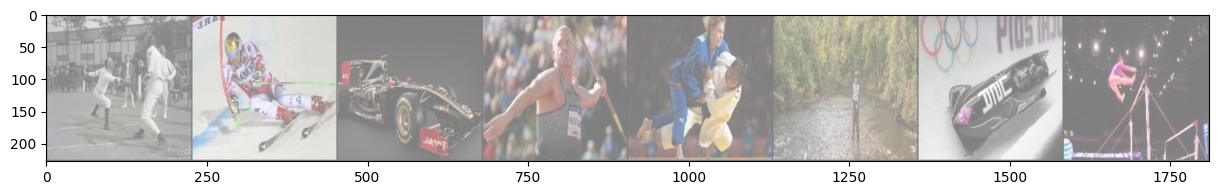

In [29]:
# from dataset import SportDataset
# from utils import matplotlib_imshow
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import pandas as pd


train_transform = transforms.Compose(
    [
    transforms.ToPILImage(mode='RGB'),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor()
    ]
)

val_transform = transforms.transforms.Compose(
    [
    transforms.ToPILImage(mode='RGB'),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
    ]
)

train_ds = SportDataset(csv_file=csv_file, class_file=class_file, root_dir=root_dir, train=True, transform=train_transform)
val_ds = SportDataset(csv_file=csv_file, class_file=class_file, root_dir=root_dir, train=False, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

class_df = pd.read_csv(class_file, usecols=['class_index', 'class'])
class_dict = { row[0]:row[1] for i, row in class_df.iterrows()}
print("class dict: ", class_dict)

dataiter = iter(train_loader)
data = next(dataiter)

plt.rcParams['figure.figsize'] = [15, 5]
# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(data['image'])
matplotlib_imshow(img_grid, one_channel=False)
print(','.join(class_dict[data['labels'][j].item()] for j in range(8)))

In [50]:
from tensorboardX import SummaryWriter # have to install pip3 install tensorboardX
import torch
import os
import errno


class Logger:
    def __init__(self, model_name, data_name):
        self.model_name = model_name
        self.data_name = data_name

        self.comment = f'{model_name}_{data_name}'
        self.data_subdir = f'{model_name}/{data_name}'

        self.writer = SummaryWriter(comment=self.comment)


    def loss_log(self, train_loss, val_loss, nth_epoch):
        self.writer.add_scalars(
            'Train vs Val Loss',
            {'Training': train_loss, 'Validation': val_loss},
            nth_epoch
        )
        
    def acc_log(self, train_acc, val_acc, nth_epoch, save_path):
        self.writer.add_scalars(
            'Train vs Val Accuracy',
            {'Training': train_acc, 'Validation': val_acc},
            nth_epoch
        )

    def save_models(self, model, nth_epoch):
        out_dir = f'saved/{self.model_name}'
        Logger._make_dir(out_dir)
        torch.save(
            model.state_dict(),
            f'{out_dir}/Ep.{nth_epoch}.pth'
        )

    def close(self):
        self.writer.close()

    @staticmethod
    def _make_dir(directory):
        try:
            os.makedirs(directory)
        except OSError as e:
            if e.errno != errno.EEXIST:
                raise

    @staticmethod
    def _step(epoch):
        pass

In [31]:
import pandas as pd
import time
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision.models.vision_transformer import vit_b_16 as ViT, ViT_B_16_Weights
from torchvision import transforms
from torch.utils.data import DataLoader
# from dataset import SportDataset
# from logger import Logger


lr = 1e-5
epoch_number = 0 # describe the starting epoch if you are continuing training
EPOCHS = 3 # number of epochs to train
model_name = 'vit_b16'
dataset_name = 'sport_dataset'

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [32]:
import os

# root_dir = 'DLCV_Lab_Dataset/sports-classification'  # Change to your dataset root

removed = 0
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.lnk'):
            file_path = os.path.join(subdir, file)
            try:
                os.remove(file_path)
                removed += 1
                print(f"Removed: {file_path}")
            except Exception as e:
                print(f"Failed to remove {file_path}: {e}")

print(f"Total .lnk files removed: {removed}")

Removed: DLCV_Lab_Dataset/sports-classification/train/high jump/159.lnk
Total .lnk files removed: 1


In [33]:
# logger = Logger(model_name, dataset_name)


# best_vloss = 100000.
# # timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# timestamp = time.time()

# for epoch in range(EPOCHS):
#     print('EPOCH {}:'.format(epoch_number + 1))
#     since = time.time()
#     # Make sure gradient tracking is on, and do a pass over the data
#     model.train(True)
#     running_loss = 0.
#     last_loss = 0.
#     running_acc = 0.
#     train_loop = tqdm(train_loader)
#     # Here, we use enumerate(training_loader) instead of
#     # iter(training_loader) so that we can track the batch
#     # index and do some intra-epoch reporting
#     for i, data in enumerate(train_loop):
#         # Every data instance is an input + label pair
#         inputs, labels = data['image'].to(device), data['labels'].long().to(device)

#         # Zero your gradients for every batch!
#         optimizer.zero_grad()

#         # Make predictions for this batch
#         outputs = model(inputs)

#         # Compute the loss and its gradients
#         loss = loss_fn(outputs, labels)
#         loss.backward()

#         # print(labels.shape, outputs.shape)
#         _, prediction = torch.max(outputs, dim=1)
#         corrects = (labels == (prediction)).sum() / len(labels)
#         running_acc += corrects

#         # Adjust learning weights
#         optimizer.step()

#         # Gather data and report
#         running_loss += loss.item()

#         train_loop.set_postfix(loss=loss.item())

#     avg_train_acc = running_acc/len(train_loader)
#     avg_train_loss = running_loss/len(train_loader)

#     print('Epoch {} loss: {}'.format(epoch_number+1, avg_train_loss))


#     # We don't need gradients on to do reporting
#     model.train(False)

#     vloop = tqdm(val_loader)
#     running_vloss = 0.0
#     running_vacc = 0.0
#     for i, data in enumerate(vloop):
#         inputs, labels = data['image'].to(device), data['labels'].long().to(device)
#         outputs = model(inputs)
#         loss = loss_fn(outputs, labels)
#         running_vloss += loss.item()

#         _, prediction = torch.max(outputs, dim=1)

#         corrects = (prediction == labels).sum() / len(labels)
#         running_vacc += corrects

#         vloop.set_postfix(loss=loss.item())

#     avg_vloss = running_vloss / len(val_loader)
#     print('LOSS train {} valid {}'.format(avg_train_loss, avg_vloss))

#     avg_vacc = running_vacc / len(val_loader)
#     print('Accuracy train {} valid {}'.format(avg_train_acc, avg_vacc))

#     # Log the running loss averaged per batch
#     # for both training and validation
#     logger.loss_log( train_loss=avg_train_loss,
#                     val_loss=avg_vloss, nth_epoch=epoch_number+1)

#     logger.acc_log( train_acc=avg_train_acc,
#                     val_acc=avg_vacc, nth_epoch=epoch_number+1)

#     # Track best performance, and save the model's state
#     if avg_vloss < best_vloss:
#         best_vloss = avg_vloss
#         model_path = 'model_{}_{}'.format(timestamp, epoch_number+1)
#         logger.save_models(model=model, nth_epoch=epoch_number+1)

#     ep_duration = time.time() - since
#     print("Epoch time taken: {:.0f}m {:.0f}s".format(ep_duration // 60, ep_duration % 60))
#     epoch_number += 1

# total_time = time.time() - timestamp
# print("Total time taken: {:.0f}m {:.0f}s".format(total_time // 60, total_time % 60))

EPOCH 1:


 34%|███▍      | 576/1687 [01:21<02:42,  6.84it/s, loss=4.7] 

Skipping file DLCV_Lab_Dataset/sports-classification/train/high jump/159.lnk: No such file: '/home/jupyter-125333/DLCV_Lab_Dataset/sports-classification/train/high jump/159.lnk'


100%|██████████| 1687/1687 [03:59<00:00,  7.05it/s, loss=4.51]


Epoch 1 loss: 4.679967668399913


...

Epoch 2 loss: 4.291817647999536


100%|██████████| 63/63 [00:04<00:00, 14.56it/s, loss=4.7] 


LOSS train 4.291817647999536 valid 4.054320267268589
Accuracy train 0.06401897221803665 valid 0.111111119389534
Epoch time taken: 4m 13s
EPOCH 3:


 58%|█████▊    | 986/1687 [02:29<01:46,  6.61it/s, loss=4.31]


KeyboardInterrupt: 

In [40]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    loop = tqdm(dataloader, desc="Training")

    for data in loop:
        inputs = data['image'].to(device)
        labels = data['labels'].long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, dim=1)
        corrects = (preds == labels).sum().item() / len(labels)
        running_acc += corrects
        running_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(dataloader)
    avg_acc = running_acc / len(dataloader)
    return avg_loss, avg_acc


def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    loop = tqdm(dataloader, desc="Validation")

    with torch.no_grad():
        for data in loop:
            inputs = data['image'].to(device)
            labels = data['labels'].long().to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            _, preds = torch.max(outputs, dim=1)
            corrects = (preds == labels).sum().item() / len(labels)
            running_acc += corrects
            running_loss += loss.item()

            loop.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(dataloader)
    avg_acc = running_acc / len(dataloader)
    return avg_loss, avg_acc

In [46]:
from tensorboardX import SummaryWriter

def log_tensorboard_metrics(writer, epoch, train_loss, val_loss, train_acc, val_acc, lr=None):
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('Accuracy/val', val_acc, epoch)
    if lr is not None:
        writer.add_scalar('LearningRate', lr, epoch)

In [51]:
def train(model, train_loader, val_loader, optimizer, loss_fn, device, logger, epochs, writer):
    best_vloss = float('inf')
    timestamp = time.time()

    for epoch in range(epochs):
        print(f"\nEPOCH {epoch + 1}:")
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, loss_fn, device)

        print(f"LOSS train {train_loss:.4f} valid {val_loss:.4f}")
        print(f"Accuracy train {train_acc:.4f} valid {val_acc:.4f}")

        logger.loss_log(train_loss=train_loss, val_loss=val_loss, nth_epoch=epoch + 1)
        logger.acc_log(train_acc=train_acc, val_acc=val_acc, nth_epoch=epoch + 1)

        # ✅ Log to TensorBoardX
        current_lr = optimizer.param_groups[0]['lr']
        log_tensorboard_metrics(writer, epoch, train_loss, val_loss, train_acc, val_acc, lr=current_lr)

        # Save model with default name
        if val_loss < best_vloss:
            best_vloss = val_loss
            model_name = f"model_{timestamp}_{epoch + 1}.pt"
            torch.save(model.state_dict(), model_name)
            print(f"Model saved: {model_name}")

        duration = time.time() - start_time
        print(f"Epoch time taken: {duration // 60:.0f}m {duration % 60:.0f}s")

    total_time = time.time() - timestamp
    print(f"\nTotal time taken: {total_time // 60:.0f}m {total_time % 60:.0f}s")

In [52]:
from tensorboardX import SummaryWriter

writer = SummaryWriter(log_dir='runs/exp1')
train(model, train_loader, val_loader, optimizer, loss_fn, device, logger, epochs=EPOCHS, writer=writer)
writer.close()


EPOCH 1:


Training:  52%|█████▏    | 875/1687 [02:09<01:59,  6.80it/s, loss=1.4]  

Skipping file DLCV_Lab_Dataset/sports-classification/train/high jump/159.lnk: No such file: '/home/jupyter-125333/DLCV_Lab_Dataset/sports-classification/train/high jump/159.lnk'


Validation: 100%|██████████| 63/63 [00:04<00:00, 13.23it/s, loss=1.26] 


LOSS train 1.3216 valid 1.2186
Accuracy train 0.7560 valid 0.7679
Model saved: model_1762759808.7525153_1.pt
Epoch time taken: 4m 16s

EPOCH 2:


...

LOSS train 1.0740 valid 1.0125
Accuracy train 0.8031 valid 0.8075
Model saved: model_1762759808.7525153_2.pt
Epoch time taken: 4m 19s

EPOCH 3:


Training:  64%|██████▍   | 1081/1687 [02:43<01:32,  6.55it/s, loss=0.658]

Skipping file DLCV_Lab_Dataset/sports-classification/train/high jump/159.lnk: No such file: '/home/jupyter-125333/DLCV_Lab_Dataset/sports-classification/train/high jump/159.lnk'


Validation: 100%|██████████| 63/63 [00:05<00:00, 11.68it/s, loss=0.815]


LOSS train 0.8994 valid 0.8841
Accuracy train 0.8387 valid 0.8214
Model saved: model_1762759808.7525153_3.pt
Epoch time taken: 4m 25s

Total time taken: 13m 1s
